In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
ftsz = 12
plt.rcParams["font.family"] = "Serif"
plt.rc('xtick', labelsize=ftsz)
plt.rc('ytick', labelsize=ftsz)

# Argon simulation in the canonical ensemble

<p align="center">
  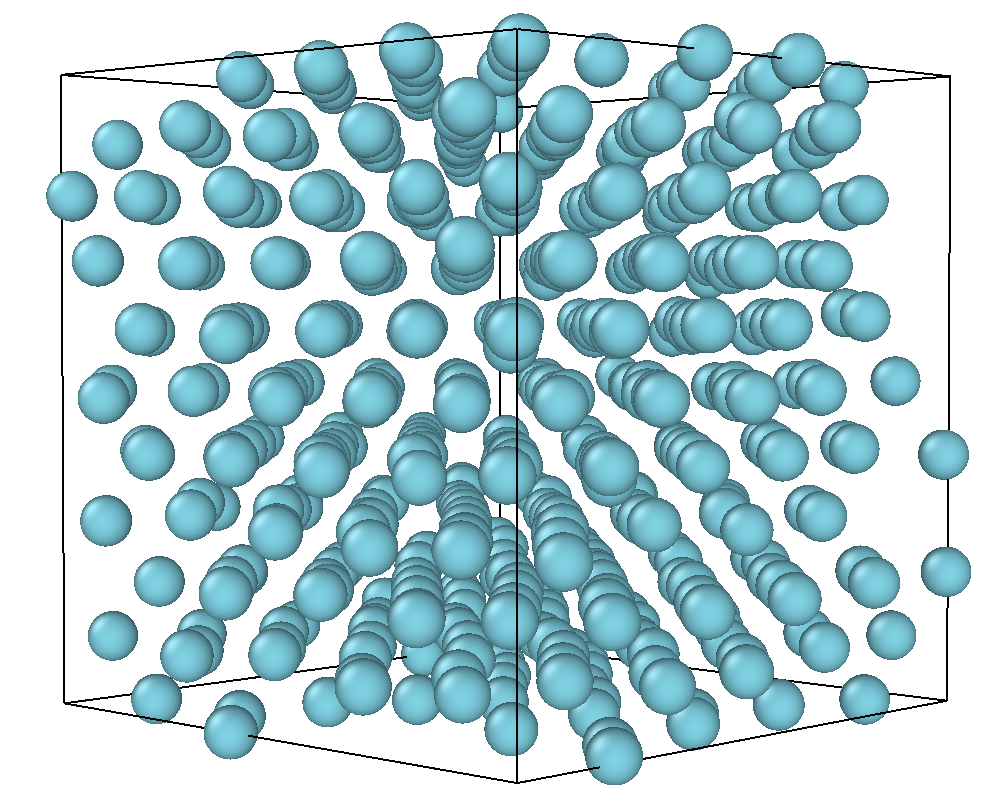
</p>

## Energy minimisation:

For the whole box (500 atoms):

$E$ = $U$ = -42.854  eV

$V$ = 18247.7 Å³

Corresponding to cohesive energy and lattice constant:

$E_{coh}$ = 85 meV

$a$ = 5.265 Å

## NVT run

Run at 35 K, 50 K and 65 K. Expect, after equilibration, fluctuating quantities about steady values.



In [7]:
# Load the data from LAMMPS. Columns: time	pe	ke	etotal	vol	press	temp

data_run_35K = np.loadtxt('Ar_nvt_35K.dat')[1000:, :] # skip the equilibration step
data_run_50K = np.loadtxt('Ar_nvt_50K.dat')[1000:, :]    # skip the equilibration step
data_run_65K = np.loadtxt('Ar_nvt_65K.dat')[1000:, :]  # skip the equilibration step

N = 500  # atoms
T = np.array([35, 50, 65]) # temperatures [K]


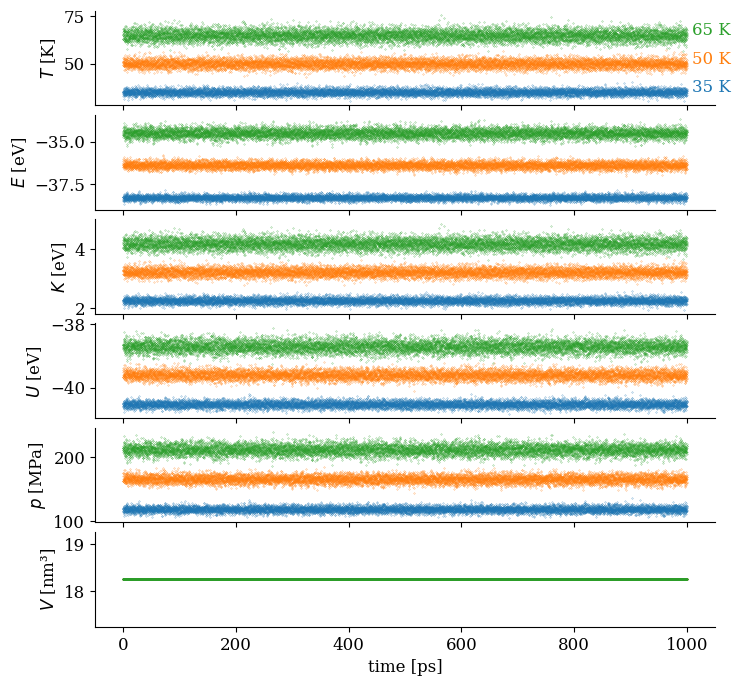

In [8]:
# Plot the time evolution

fig, ax = plt.subplots(6, 1, figsize=(8, 8), sharex=True, gridspec_kw={"hspace": 0.1})

# Each entry: (column index in data, scale_factor, ylabel)
channels = [
    (6, 1,          r"$T$ [K]"),
    (3, 1,  r"$E$ [eV]"),
    (2, 1,  r"$K$ [eV]"),
    (1, 1,  r"$U$ [eV]"),
    (5, 0.101325,   r"$p$ [MPa]"),
    (4, 1e-3,       r"$V$ [nm³]"),
]

for i, data in enumerate([data_run_35K, data_run_50K, data_run_65K]):
    t = (data[:, 0] - data[0, 0])
    for axis, (col, scale, label) in zip(ax, channels):
        axis.plot(t, scale * data[:, col], 'o', markersize=0.2, color=f'C{i}')
    
    ax[0].text(1010, T[i], f"{T[i]} K", color=f'C{i}', fontsize=ftsz) # legend

for axis, (_, _, label) in zip(ax, channels):
    axis.set_ylabel(label, fontsize=ftsz)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
ax[5].set_xlabel("time [ps]", fontsize=ftsz)

plt.show()


# Estimate heat capacity in the canonical ensemble

We will use the fact that given the total energy $E$, sum of potential and kinetic energy:

$$ \langle E^2\rangle - \langle E\rangle^2 = \sigma_E = k_BT^2C_V $$

to estimate $C_V$ in the classical limit of the Dulong-Petit law.

This will give us the heat capacity $C_V$ of the simulation box. To obtain the molar specific heat capacity $c_V$, we scale using the number of atoms in the simulation $N$ with respect to Avogadro's number $N_A$:
$$ c_v = \frac{\sigma_E}{k_BT^2}\frac{N_A}{N} $$


NOTE: there is no quantum behaviour in classical MD! We shall not see any temperature dependence in $c_V$, but expect a constant value approaching $c_V \approx 3R$=24.9 J/mol/K.

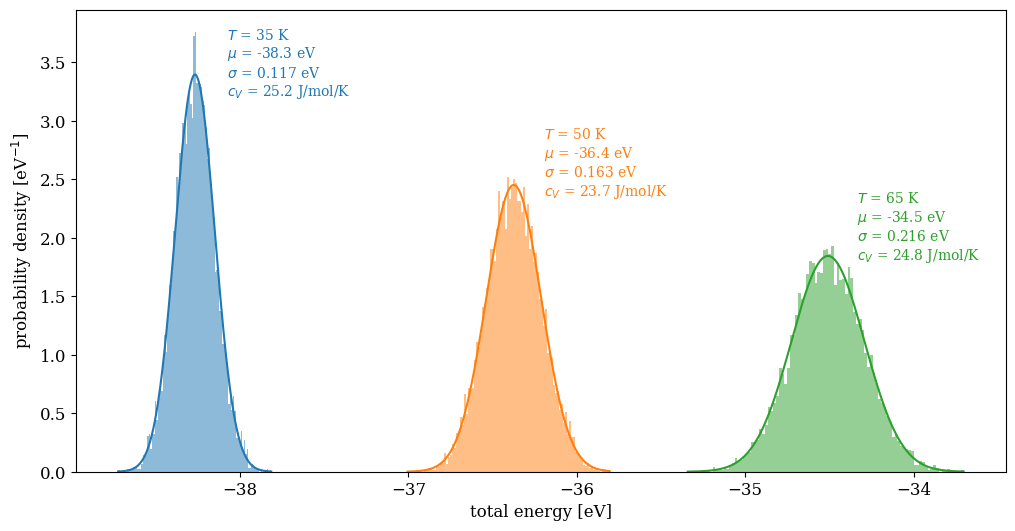

In [10]:
plt.figure(figsize=(12, 6))
for i, data in enumerate([data_run_35K, data_run_50K, data_run_65K]):
    E = data[:, 3] # eV
    x = np.linspace(E.min(), E.max(), 300)

    # plot the histogram of the total energy
    plt.hist(E, bins=100, density=True, color=f'C{i}', alpha=0.5)
    # fit a Gaussian and plot it alongside
    mu, sigma = scipy.stats.norm.fit(E)
    pdf = scipy.stats.norm.pdf(x, mu, sigma)
    plt.plot(x, pdf)
    # estimation of 
    c_V = sigma**2/(8.6173e-5*T[i]**2)*1.602e-19*6.022e23/N

    plt.text(mu*0.995, pdf.max()*0.9, f"$T$ = {T[i]:.3g} K\n$\mu$ = {mu:.3g} eV\n$\sigma$ = {sigma:.3g} eV\n$c_V$ = {c_V:.3g} J/mol/K\n", color=f'C{i}')

plt.xlabel('total energy [eV]', fontsize=ftsz)
plt.ylabel(r'probability density [eV$^{-1}$]', fontsize=ftsz)
plt.show()